In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np

DEVICE      = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE  = 128
NUM_EPOCHS  = 30
NUM_WORKERS = 2
print(f"Using device: {DEVICE}")

Using device: cuda


In [2]:
# ─────────────────────────────────────────────
# 1. Data loading and augmentation
# ─────────────────────────────────────────────

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616)),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616)),
])

full_train = torchvision.datasets.CIFAR10(root="./data", train=True,
                                          download=True, transform=train_transform)
test_set   = torchvision.datasets.CIFAR10(root="./data", train=False,
                                          download=True, transform=test_transform)

# 45k train / 5k val split
train_size = int(0.9 * len(full_train))
val_size   = len(full_train) - train_size

train_set, val_set = random_split(full_train, [train_size, val_size], generator=torch.Generator().manual_seed(42))
# val set should use test-time transforms
val_set.dataset = torchvision.datasets.CIFAR10(root="./data", train=True,
                                               download=False, transform=test_transform)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

100%|██████████| 170M/170M [00:02<00:00, 83.9MB/s] 


In [3]:
# ─────────────────────────────────────────────
# 2. Model definitions
# ─────────────────────────────────────────────

# ── Model 1: Shallow CNN ──────────────────────
class ShallowCNN(nn.Module):
    """2 conv blocks + FC head. No BN."""
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),   # 32×32 → 32×32
            nn.ReLU(),
            nn.MaxPool2d(2),                   # 16×16

            nn.Conv2d(32, 64, 3, padding=1),  # 16×16
            nn.ReLU(),
            nn.MaxPool2d(2),                   # 8×8
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 10),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


# ── Model 2: Shallow CNN + BatchNorm ─────────
class ShallowCNN_BN(nn.Module):
    """Same as Model 1 but with BN after every conv."""
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 10),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


# ── Model 3: Deep CNN (no skip connections) ───
class DeepCNN(nn.Module):
    """
    6 conv blocks with progressive channel widening.
    Uses BN throughout. No skip connections.
    """
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1 — 32×32
            nn.Conv2d(3,  64, 3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(),
            nn.MaxPool2d(2),                                        # 16×16

            # Block 2 — 16×16
            nn.Conv2d(64,  128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2),                                         # 8×8

            # Block 3 — 8×8
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.MaxPool2d(2),                                         # 4×4
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),   # Global Average Pooling → 256×1×1
            nn.Flatten(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 10),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


# ── Model 4: ResNet-style (skip connections) ──
class ResidualBlock(nn.Module):
    """
    Pre-activation style residual block (READ MORE IN He et al. 2016, "Identity Mappings"):
      BN → ReLU → Conv → BN → ReLU → Conv → (+x)
    1x1 projection shortcut when channels change.
    """
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.BatchNorm2d(in_ch),
            nn.ReLU(),
            nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
        )
        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False)

    def forward(self, x):
        return self.block(x) + self.shortcut(x)


class ResNet(nn.Module):
    """
    Small ResNet:
      Stem → Stage1(64) → Stage2(128) → Stage3(256) → GAP → FC
    Each stage = 2 residual blocks.
    """
    def __init__(self):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(),
        )
        self.stage1 = nn.Sequential(
            ResidualBlock(64,  64),
            ResidualBlock(64,  64),
        )
        self.stage2 = nn.Sequential(
            ResidualBlock(64,  128, stride=2),
            ResidualBlock(128, 128),
        )
        self.stage3 = nn.Sequential(
            ResidualBlock(128, 256, stride=2),
            ResidualBlock(256, 256),
        )
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(256, 10),
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        return self.head(x)

In [4]:
# ─────────────────────────────────────────────
# 3. Eval helper
# ─────────────────────────────────────────────

def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            logits = model(imgs)
            total_loss += criterion(logits, labels).item() * labels.size(0)
            correct    += (logits.argmax(1) == labels).sum().item()
            total      += labels.size(0)
    return total_loss / total, correct / total

In [5]:
# ── Model 1: Shallow CNN ──────────────────────
print("\n" + "="*55)
print("  Model 1: Shallow CNN")
print("="*55)

model1    = ShallowCNN().to(DEVICE)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.Adam(model1.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)
history1  = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for epoch in range(1, NUM_EPOCHS + 1):
    model1.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        logits = model1(imgs)
        loss   = criterion(logits, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * labels.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += labels.size(0)
    scheduler.step()

    tr_loss, tr_acc = total_loss / total, correct / total
    va_loss, va_acc = evaluate(model1, val_loader, criterion)
    history1["train_loss"].append(tr_loss); history1["val_loss"].append(va_loss)
    history1["train_acc"].append(tr_acc);  history1["val_acc"].append(va_acc)

    if epoch % 5 == 0 or epoch == 1:
        print(f"  Epoch {epoch:3d}/{NUM_EPOCHS} | "
              f"Train loss={tr_loss:.4f} acc={tr_acc:.3f} | "
              f"Val loss={va_loss:.4f} acc={va_acc:.3f}")

_, test_acc1 = evaluate(model1, test_loader, criterion)
print(f"  Test accuracy: {test_acc1*100:.2f}%")


  Model 1: Shallow CNN
  Epoch   1/30 | Train loss=1.8136 acc=0.390 | Val loss=1.5376 acc=0.534
  Epoch   5/30 | Train loss=1.4004 acc=0.606 | Val loss=1.2419 acc=0.679
  Epoch  10/30 | Train loss=1.2924 acc=0.664 | Val loss=1.1594 acc=0.724
  Epoch  15/30 | Train loss=1.2304 acc=0.695 | Val loss=1.1038 acc=0.755
  Epoch  20/30 | Train loss=1.1902 acc=0.717 | Val loss=1.0800 acc=0.762
  Epoch  25/30 | Train loss=1.1533 acc=0.734 | Val loss=1.0609 acc=0.770
  Epoch  30/30 | Train loss=1.1460 acc=0.738 | Val loss=1.0560 acc=0.772
  Test accuracy: 77.18%


In [6]:
# ── Model 2: Shallow CNN + BN ─────────────────
print("\n" + "="*55)
print("  Model 2: Shallow CNN + BatchNorm")
print("="*55)

model2    = ShallowCNN_BN().to(DEVICE)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.Adam(model2.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)
history2  = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for epoch in range(1, NUM_EPOCHS + 1):
    model2.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        logits = model2(imgs)
        loss   = criterion(logits, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * labels.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += labels.size(0)
    scheduler.step()

    tr_loss, tr_acc = total_loss / total, correct / total
    va_loss, va_acc = evaluate(model2, val_loader, criterion)
    history2["train_loss"].append(tr_loss); history2["val_loss"].append(va_loss)
    history2["train_acc"].append(tr_acc);  history2["val_acc"].append(va_acc)

    if epoch % 5 == 0 or epoch == 1:
        print(f"  Epoch {epoch:3d}/{NUM_EPOCHS} | "
              f"Train loss={tr_loss:.4f} acc={tr_acc:.3f} | "
              f"Val loss={va_loss:.4f} acc={va_acc:.3f}")

_, test_acc2 = evaluate(model2, test_loader, criterion)
print(f"  Test accuracy: {test_acc2*100:.2f}%")


  Model 2: Shallow CNN + BatchNorm
  Epoch   1/30 | Train loss=1.9306 acc=0.329 | Val loss=1.6241 acc=0.480
  Epoch   5/30 | Train loss=1.6146 acc=0.496 | Val loss=1.3651 acc=0.628
  Epoch  10/30 | Train loss=1.5189 acc=0.548 | Val loss=1.3014 acc=0.657
  Epoch  15/30 | Train loss=1.4554 acc=0.582 | Val loss=1.2343 acc=0.695
  Epoch  20/30 | Train loss=1.4073 acc=0.612 | Val loss=1.1637 acc=0.723
  Epoch  25/30 | Train loss=1.3675 acc=0.632 | Val loss=1.1481 acc=0.735
  Epoch  30/30 | Train loss=1.3515 acc=0.637 | Val loss=1.1376 acc=0.739
  Test accuracy: 74.58%


In [7]:
# ── Model 3: Deep CNN ─────────────────────────
print("\n" + "="*55)
print("  Model 3: Deep CNN (no skip connections)")
print("="*55)

model3    = DeepCNN().to(DEVICE)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.SGD(model3.parameters(), lr=0.01,
                      momentum=0.9, weight_decay=5e-4, nesterov=True)
scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=0.1,
                                          steps_per_epoch=len(train_loader),
                                          epochs=NUM_EPOCHS)
history3  = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for epoch in range(1, NUM_EPOCHS + 1):
    model3.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        logits = model3(imgs)
        loss   = criterion(logits, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()          # OneCycleLR steps per batch, not per epoch
        total_loss += loss.item() * labels.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += labels.size(0)

    tr_loss, tr_acc = total_loss / total, correct / total
    va_loss, va_acc = evaluate(model3, val_loader, criterion)
    history3["train_loss"].append(tr_loss); history3["val_loss"].append(va_loss)
    history3["train_acc"].append(tr_acc);  history3["val_acc"].append(va_acc)

    if epoch % 5 == 0 or epoch == 1:
        print(f"  Epoch {epoch:3d}/{NUM_EPOCHS} | "
              f"Train loss={tr_loss:.4f} acc={tr_acc:.3f} | "
              f"Val loss={va_loss:.4f} acc={va_acc:.3f}")

_, test_acc3 = evaluate(model3, test_loader, criterion)
print(f"  Test accuracy: {test_acc3*100:.2f}%")


  Model 3: Deep CNN (no skip connections)
  Epoch   1/30 | Train loss=1.6972 acc=0.436 | Val loss=1.4651 acc=0.552
  Epoch   5/30 | Train loss=1.0447 acc=0.778 | Val loss=1.0953 acc=0.747
  Epoch  10/30 | Train loss=0.8783 acc=0.852 | Val loss=0.9181 acc=0.827
  Epoch  15/30 | Train loss=0.8112 acc=0.879 | Val loss=0.9264 acc=0.815
  Epoch  20/30 | Train loss=0.7506 acc=0.908 | Val loss=0.8542 acc=0.850
  Epoch  25/30 | Train loss=0.6723 acc=0.942 | Val loss=0.7593 acc=0.899
  Epoch  30/30 | Train loss=0.5890 acc=0.982 | Val loss=0.6921 acc=0.925
  Test accuracy: 91.84%


In [12]:
# ── Model 4: ResNet ───────────────────────────
print("\n" + "="*55)
print("  Model 4: ResNet (skip connections)")
print("="*55)

model4    = ResNet().to(DEVICE)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.SGD(model4.parameters(), lr=0.01,
                      momentum=0.9, weight_decay=5e-4, nesterov=True)
scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=0.1,
                                          steps_per_epoch=len(train_loader),
                                          epochs=NUM_EPOCHS)
history4  = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for epoch in range(1, NUM_EPOCHS + 1):
    model4.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        logits = model4(imgs)
        loss   = criterion(logits, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()          # OneCycleLR steps per batch, not per epoch
        total_loss += loss.item() * labels.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += labels.size(0)

    tr_loss, tr_acc = total_loss / total, correct / total
    va_loss, va_acc = evaluate(model4, val_loader, criterion)
    history4["train_loss"].append(tr_loss); history4["val_loss"].append(va_loss)
    history4["train_acc"].append(tr_acc);  history4["val_acc"].append(va_acc)

    if epoch % 5 == 0 or epoch == 1:
        print(f"  Epoch {epoch:3d}/{NUM_EPOCHS} | "
              f"Train loss={tr_loss:.4f} acc={tr_acc:.3f} | "
              f"Val loss={va_loss:.4f} acc={va_acc:.3f}")

_, test_acc4 = evaluate(model4, test_loader, criterion)
print(f"  Test accuracy: {test_acc4*100:.2f}%")



  Model 4: ResNet (skip connections)
  Epoch   1/30 | Train loss=1.6920 acc=0.442 | Val loss=1.8702 acc=0.459
  Epoch   5/30 | Train loss=1.0070 acc=0.794 | Val loss=1.1043 acc=0.758
  Epoch  10/30 | Train loss=0.8321 acc=0.870 | Val loss=0.8932 acc=0.850
  Epoch  15/30 | Train loss=0.7657 acc=0.900 | Val loss=0.9208 acc=0.837
  Epoch  20/30 | Train loss=0.7224 acc=0.918 | Val loss=0.8242 acc=0.875
  Epoch  25/30 | Train loss=0.6232 acc=0.962 | Val loss=0.7108 acc=0.921
  Epoch  30/30 | Train loss=0.5488 acc=0.994 | Val loss=0.6640 acc=0.938
  Test accuracy: 93.57%



  Final Test Accuracies
  ShallowCNN          : 77.18%
  ShallowCNN+BN       : 74.58%
  DeepCNN             : 91.84%
  ResNet              : 93.57%


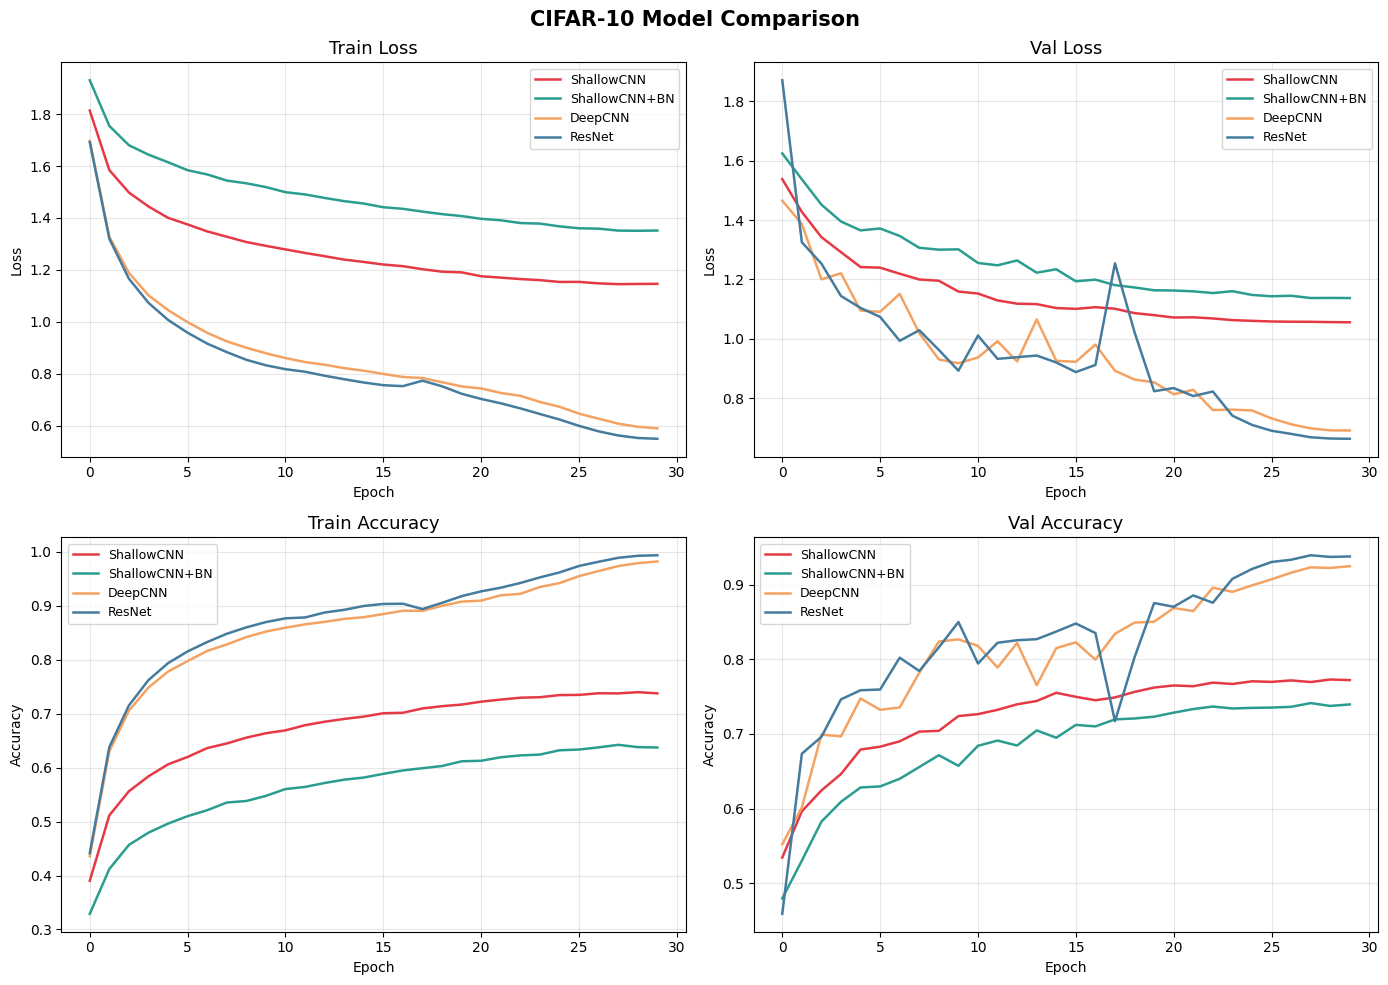

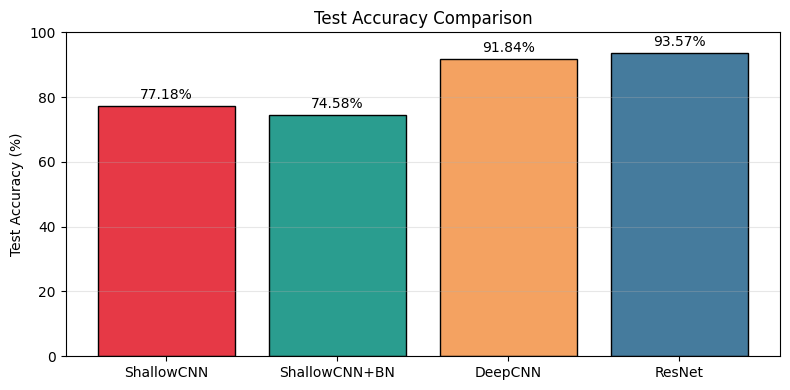

In [13]:
# ─────────────────────────────────────────────
# 4. Plotting
# ─────────────────────────────────────────────

histories = [history1, history2, history3, history4]
names     = ["ShallowCNN", "ShallowCNN+BN", "DeepCNN", "ResNet"]
test_accs = [test_acc1, test_acc2, test_acc3, test_acc4]
colors    = ["#e63946", "#2a9d8f", "#f4a261", "#457b9d"]

print("\n" + "="*55)
print("  Final Test Accuracies")
print("="*55)
for name, acc in zip(names, test_accs):
    print(f"  {name:<20s}: {acc*100:.2f}%")

# Loss and accuracy curves
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax_row, metric, ylabel in zip(
    [axes[0], axes[1]], ["loss", "acc"], ["Loss", "Accuracy"]
):
    for ax, split in zip(ax_row, ["train", "val"]):
        for h, name, c in zip(histories, names, colors):
            ax.plot(h[f"{split}_{metric}"], label=name, color=c, linewidth=1.8)
        ax.set_title(f"{split.capitalize()} {ylabel}", fontsize=13)
        ax.set_xlabel("Epoch")
        ax.set_ylabel(ylabel)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

plt.suptitle("CIFAR-10 Model Comparison", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("cifar10_curves.png", dpi=150)
plt.show()

# Summary bar chart
fig2, ax2 = plt.subplots(figsize=(8, 4))
bars = ax2.bar(names, [a * 100 for a in test_accs], color=colors, edgecolor="black")
ax2.bar_label(bars, fmt="%.2f%%", padding=3)
ax2.set_ylabel("Test Accuracy (%)")
ax2.set_title("Test Accuracy Comparison")
ax2.set_ylim(0, 100)
ax2.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("cifar10_summary.png", dpi=150)
plt.show()